<a href="https://colab.research.google.com/github/ngtuanduy12/Intent-analysis-project/blob/main/DoAn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib underthesea transformers torch

In [ ]:
import pandas as pd

# 👉 sửa đường dẫn file tại đây
file_path = "Data_cleaned.csv"

try:
    df = pd.read_csv(file_path,sep=';', encoding="utf-8-sig")
except Exception as e:
    print("Lỗi đọc file:", e)
    raise

print("📊 Số lượng mẫu:", len(df))

# Chuẩn hóa tên cột (phòng lỗi Excel)
df.columns = df.columns.str.strip()

# Check missing
print("\n❗ Missing values:")
print(df.isnull().sum())

df = df.dropna()

print("\n📊 Phân bố intent:")
print(df["Intent"].value_counts())

In [ ]:
from sklearn.model_selection import train_test_split

X = df["Text"]
y = df["Intent"]

# 70% train
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# chia 30% còn lại → 10% val, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, stratify=y_temp, random_state=42
)

print("Train:", len(X_train))
print("Val:", len(X_val))
print("Test:", len(X_test))

In [ ]:
from underthesea import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score
import joblib
from google.colab import drive
drive.mount('/content/drive')

# tokenize tiếng Việt
def tokenize(text):
    return word_tokenize(text, format="text")

X_train_tok = [tokenize(x) for x in X_train]
X_val_tok   = [tokenize(x) for x in X_val]
X_test_tok  = [tokenize(x) for x in X_test]

# TF-IDF
vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train_tok)
X_val_vec   = vectorizer.transform(X_val_tok)
X_test_vec  = vectorizer.transform(X_test_tok)

# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

# Evaluate
def evaluate(X, y, name):
    y_pred = model.predict(X)
    print(f"\n===== {name} =====")
    print(classification_report(y, y_pred))
    return accuracy_score(y, y_pred), f1_score(y, y_pred, average="macro")

acc_base, f1_base = evaluate(X_test_vec, y_test, "Baseline Test")

# Save
joblib.dump(
    vectorizer,
    "/content/drive/MyDrive/tfidf.pkl"
)

joblib.dump(
    model,
    "/content/drive/MyDrive/logreg.pkl"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

===== Baseline Test =====
                precision    recall  f1-score   support

      ask_time       0.89      0.94      0.92        18
   ask_weather       0.86      1.00      0.92        18
      close_tv       0.85      0.73      0.79        15
       open_tv       0.93      0.82      0.88        17
    play_music       0.71      0.94      0.81        18
    stop_music       0.92      0.67      0.77        18
  turn_off_fan       0.94      1.00      0.97        17
turn_off_light       0.90      1.00      0.95        18
   turn_on_fan       0.94      0.88      0.91        17
 turn_on_light       0.93      0.78      0.85        18

      accuracy                           0.88       174
     macro avg       0.89      0.88      0.88       174
  weighted avg       0.89      0.88      0.88       174



['/content/drive/MyDrive/logreg.pkl']

In [ ]:
import torch
import numpy as np
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from transformers import set_seed

In [ ]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)
print(le.classes_)

['ask_time' 'ask_weather' 'close_tv' 'open_tv' 'play_music' 'stop_music'
 'turn_off_fan' 'turn_off_light' 'turn_on_fan' 'turn_on_light']


In [ ]:
class IntentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

model_pho = AutoModelForSequenceClassification.from_pretrained(
    "vinai/phobert-base",
    num_labels=len(le.classes_)
)

train_dataset = IntentDataset(X_train, y_train_enc, tokenizer)
val_dataset   = IntentDataset(X_val, y_val_enc, tokenizer)
set_seed(42)

args = TrainingArguments(
    output_dir="./phobert",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5
)

trainer = Trainer(
    model=model_pho,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer.train()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.decoder.bias            | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initia

Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=190, training_loss=1.6744651392886514, metrics={'train_runtime': 4652.3197, 'train_samples_per_second': 0.65, 'train_steps_per_second': 0.041, 'total_flos': 198992027942400.0, 'train_loss': 1.6744651392886514, 'epoch': 5.0})

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



===== PhoBERT =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.82      1.00      0.90        18
           2       1.00      0.87      0.93        15
           3       0.94      0.88      0.91        17
           4       0.68      0.94      0.79        18
           5       0.91      0.56      0.69        18
           6       1.00      1.00      1.00        17
           7       0.94      0.94      0.94        18
           8       1.00      0.94      0.97        17
           9       0.94      0.94      0.94        18

    accuracy                           0.91       174
   macro avg       0.92      0.91      0.91       174
weighted avg       0.92      0.91      0.91       174



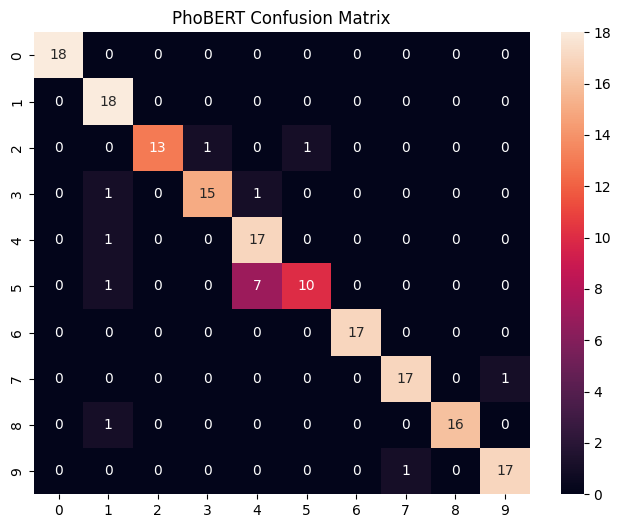


===== SO SÁNH =====
      Model  Accuracy  Macro F1
0  Baseline  0.879310   0.87628
1   PhoBERT  0.908046   0.90766


In [ ]:

test_dataset = IntentDataset(X_test, y_test_enc, tokenizer)

preds = trainer.predict(test_dataset)
y_pred = np.argmax(preds.predictions, axis=1)

from sklearn.metrics import classification_report

print("\n===== PhoBERT =====")
print(classification_report(y_test_enc, y_pred))

acc_pho = accuracy_score(y_test_enc, y_pred)
f1_pho  = f1_score(y_test_enc, y_pred, average="macro")

from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test_enc, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("PhoBERT Confusion Matrix")
plt.show()

import pandas as pd

result = pd.DataFrame({
    "Model": ["Baseline", "PhoBERT"],
    "Accuracy": [acc_base, acc_pho],
    "Macro F1": [f1_base, f1_pho]
})

print("\n===== SO SÁNH =====")
print(result)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

trainer.save_model("/content/drive/MyDrive/phobert_model")
tokenizer.save_pretrained("/content/drive/MyDrive/phobert_model")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/phobert_model/tokenizer_config.json',
 '/content/drive/MyDrive/phobert_model/vocab.txt',
 '/content/drive/MyDrive/phobert_model/bpe.codes',
 '/content/drive/MyDrive/phobert_model/added_tokens.json')

In [1]:
# =========================================
# INSTALL (chạy 1 lần trên Colab)
# =========================================
!pip install fastapi uvicorn pyngrok nest_asyncio underthesea transformers


# =========================================
# IMPORT
# =========================================
from fastapi import FastAPI
import threading
import torch
import joblib

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

from underthesea import word_tokenize

from pyngrok import ngrok
import nest_asyncio
import uvicorn

from google.colab import drive
drive.mount('/content/drive')
# =========================================
# LOAD BASELINE MODEL
# =========================================
vectorizer = joblib.load(
    "/content/drive/MyDrive/tfidf.pkl"
)

model_base = joblib.load(
    "/content/drive/MyDrive/logreg.pkl"
)


# =========================================
# LOAD PHOBERT MODEL
# =========================================
tokenizer = AutoTokenizer.from_pretrained(
    "/content/drive/MyDrive/phobert_model"
)

model_pho = AutoModelForSequenceClassification.from_pretrained(
    "/content/drive/MyDrive/phobert_model"
)
# =========================================
# LABELS
# =========================================
labels = [
    'ask_time',
    'ask_weather',
    'close_tv',
    'open_tv',
    'play_music',
    'stop_music',
    'turn_off_fan',
    'turn_off_light',
    'turn_on_fan',
    'turn_on_light'
]

# =========================================
# FASTAPI
# =========================================
app = FastAPI()


# =========================================
# TOKENIZE CHO BASELINE
# =========================================
def tokenize(text):

    return word_tokenize(
        text,
        format="text"
    )
# =========================================
# API PREDICT
# =========================================
@app.get("/predict")
def predict(text: str):

    # ========= BASELINE =========
    text_tok = tokenize(text)

    text_vec = vectorizer.transform([text_tok])

    pred_base = model_base.predict(text_vec)[0]


    # ========= PHOBERT =========
    enc = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=128
    )

    outputs = model_pho(**enc)

    pred_pho = torch.argmax(
        outputs.logits,
        dim=1
    ).item()

    pred_pho = labels[pred_pho]


    # ========= RETURN =========
    return {
        "input_text": text,
        "baseline_prediction": pred_base,
        "phobert_prediction": pred_pho
    }


# =========================================
# RUN API
# =========================================
nest_asyncio.apply()
ngrok.set_auth_token("3EFk9m9cwxUORKmslIdXjqrZMJQ_2C2T9MNsvqguzk6LqYRbL")
public_url = ngrok.connect(8000)

print("Public URL:", public_url)

# hàm chạy server
def run():
    uvicorn.run(
        app,
        host="0.0.0.0",
        port=8000
    )

# chạy background thread
thread = threading.Thread(target=run)
thread.start()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.3 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Public URL: NgrokTunnel: "https://darkish-spinning-reveal.ngrok-free.dev" -> "http://localhost:8000"
